#Introduction

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Data Loading

In [24]:
df = pd.read_csv("online_retail.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


##Data Understanding

In [25]:
df.shape

(480556, 8)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480556 entries, 0 to 480555
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      480556 non-null  object 
 1   StockCode    480556 non-null  object 
 2   Description  479149 non-null  object 
 3   Quantity     480556 non-null  int64  
 4   InvoiceDate  480556 non-null  object 
 5   Price        480556 non-null  float64
 6   Customer ID  362215 non-null  float64
 7   Country      480555 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 29.3+ MB


In [27]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1407
Quantity,0
InvoiceDate,0
Price,0
Customer ID,118341
Country,1


In [28]:
df.describe()

,Quantity,Price,Customer ID
count,480556.000000,480556.000000,362215.000000
mean,9.724047,4.629374,15280.553409
std,160.868757,97.429050,1713.715882
min,-74215.000000,-11062.060000,18.000000
25%,1.000000,1.250000,13911.000000
50%,3.000000,2.080000,15150.000000
75%,10.000000,4.130000,16782.000000
max,74215.000000,38970.000000,18287.000000


In [29]:
df.duplicated().sum()

np.int64(4347)

In [30]:
df = df.drop_duplicates()

In [31]:
df.duplicated().sum()

np.int64(0)

##Data Cleaning

In [32]:
df = df.dropna(subset=["Description"])

In [33]:
df = df.drop(columns=["Customer ID"], errors='ignore')

In [34]:
df = df[df["Quantity"] > 0]

In [35]:
df = df[df["Price"] > 0]

In [36]:
df.shape

(465381, 7)

In [37]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True)

In [38]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [39]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

In [40]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,Revenue,Year,Month,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...
480551,577310,23444,Next Day Carriage,1,2011-11-18 13:15:00,15.00,United Kingdom,15.00,2011,11,18,Friday
480552,577311,22112,CHOCOLATE HOT WATER BOTTLE,1,2011-11-18 13:16:00,4.95,United Kingdom,4.95,2011,11,18,Friday
480553,577311,23355,HOT WATER BOTTLE KEEP CALM,1,2011-11-18 13:16:00,4.95,United Kingdom,4.95,2011,11,18,Friday
480554,577311,23581,JUMBO BAG PAISLEY PARK,1,2011-11-18 13:16:00,2.08,United Kingdom,2.08,2011,11,18,Friday


## Exploratory Data Analysis (EDA)

##Monthly Revenue Trend

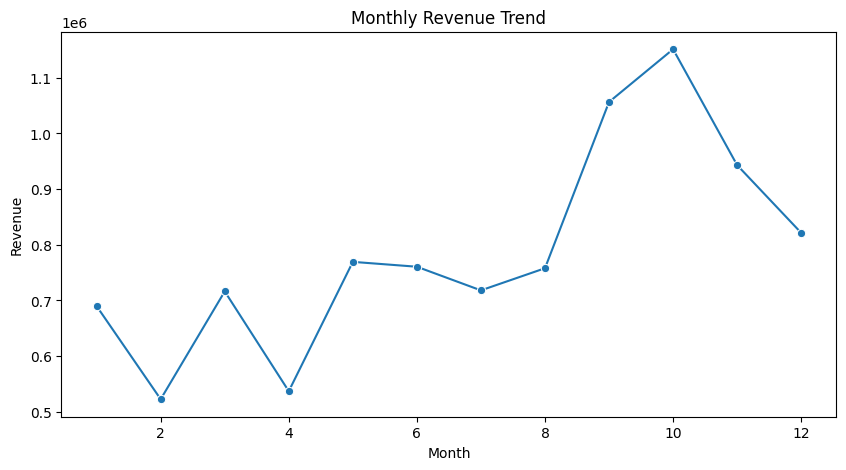

In [41]:
monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue, x="Month", y="Revenue", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

##Top 10 Products by Revenue

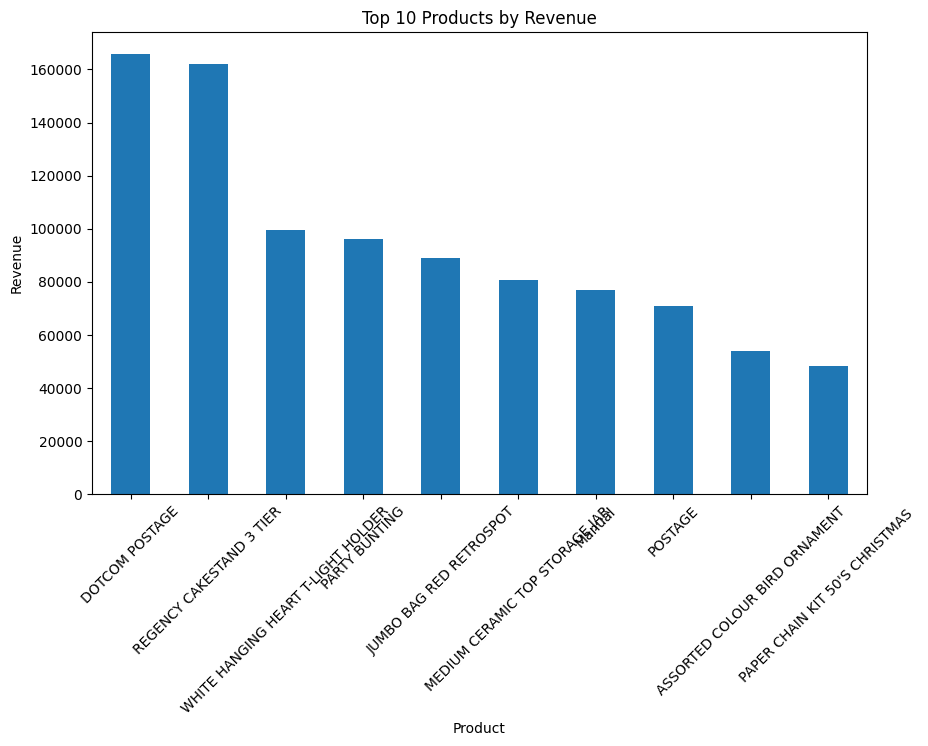

In [42]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

##Top Countries by Revenue

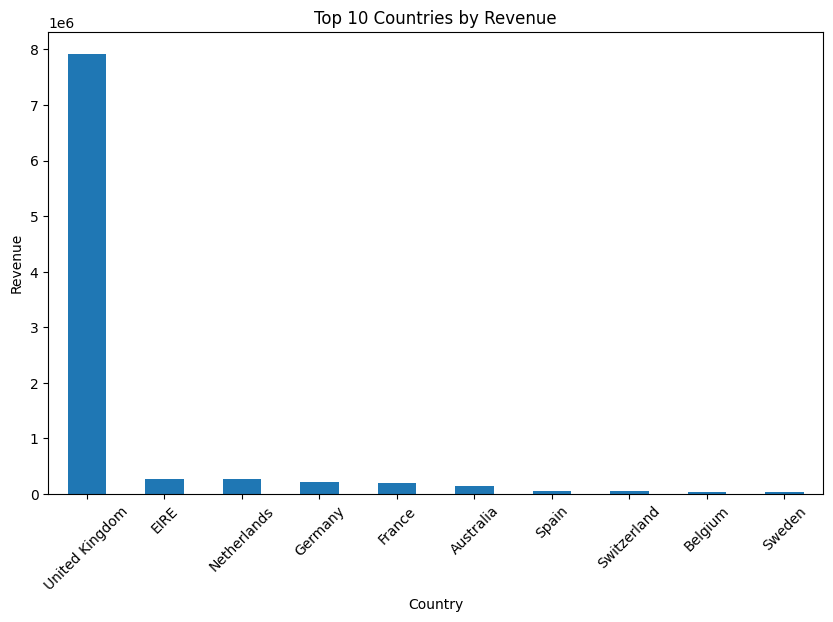

In [43]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

##Day of Week Sales Pattern